In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 数据预处理

In [2]:
df_share_price = pd.read_csv("./AShareEODPrices/eod.csv",encoding="gbk")
df_index_price = pd.read_csv("AIndexEODPrices.csv",encoding="gbk")
df_indicator = pd.read_csv("./AShareEODDerivativeIndicator/eodde.csv",encoding="gbk")
df_class = pd.read_csv("AShareIndustriesClassCITICS.csv",encoding="gbk")

In [3]:
#股票数据预处理，日期为交易日,pctchange是次日对上一日的变化率
df_stk = df_share_price[df_share_price['s_dq_tradestatus']=='交易'].copy() #只保留在交易的股票数据
# df_stk = df_stk[(df_stk['s_info_windcode'].str[7:]=='SZ') | (df_stk['s_info_windcode'].str[7:]=='SH')] #只保留SH和SZ的股票
df_stk = df_stk[(df_stk['s_dq_pctchange']<21) &(df_stk['s_dq_pctchange']>-21) ]#除去超过涨停和跌停的数据
df_stk = df_stk[['s_info_windcode','trade_dt','s_dq_pctchange']]
df_stk['trade_dt'] = pd.to_datetime(df_stk['trade_dt'].astype(str),format='%Y-%m-%d')
df_stk.sort_values(by=['s_info_windcode','trade_dt'],inplace=True)
stk_code = df_stk['s_info_windcode'].unique()

df_stk.head(5)

,s_info_windcode,trade_dt,s_dq_pctchange
0,000001.SZ,2023-08-31,0.0000
5273,000001.SZ,2023-09-01,1.7071
10548,000001.SZ,2023-09-04,2.1201
15824,000001.SZ,2023-09-05,-1.4706
21101,000001.SZ,2023-09-06,0.3512


In [4]:
#市场数据预处理，日期为交易日，截至2025-02-28' 
df_mkt = df_index_price[df_index_price['s_info_windcode']=='000906.SH'].copy() #只保留中证800指数数据
df_mkt = df_mkt[['trade_dt','s_dq_pctchange']]
df_mkt['trade_dt'] = pd.to_datetime(df_mkt['trade_dt'].astype(str),format='%Y-%m-%d')

df_mkt.head(5)

,trade_dt,s_dq_pctchange
522,2022-12-29,-0.3009
523,2022-12-30,0.3192
524,2023-01-03,0.7098
525,2023-01-04,0.0817
526,2023-01-05,1.6947


In [5]:
#行业数据预处理
df_class['entry_dt'] = pd.to_datetime(df_class['entry_dt'].astype(str),format='%Y-%m-%d')
df_class['remove_dt'] = pd.to_datetime(df_class['remove_dt'].astype(str),format='%Y-%m-%d')
df_class = df_class[df_class['remove_dt']>=pd.to_datetime('2023-12-01')] #只保留remove_dt >= 2023-12-01
df_class.drop('trade_dt',axis=1,inplace=True)
df_class = df_class[df_class['s_info_windcode'].isin(stk_code)]#只保留交易的股票

df_class.head(5)

,s_info_windcode,industriescode,entry_dt,remove_dt,cur_sign,industriesname
0,000001.SZ,b10l,2003-01-01,2027-11-27,1,银行
1,000002.SZ,b10n,2003-01-01,2027-11-27,1,房地产
4,000004.SZ,b10r,2022-12-13,2027-11-27,1,计算机
7,000005.SZ,b104,2019-12-02,2027-11-27,1,电力及公用事业
8,000006.SZ,b10n,2003-01-01,2027-11-27,1,房地产


In [6]:
#因子数据预处理，截至'2025-02-28' 
df_fct = df_indicator[['trade_dt','s_info_windcode','s_val_pe','s_val_mv']].copy()
df_fct = df_fct[df_fct['s_info_windcode'].isin(stk_code)] #只保留交易的股票
df_fct['trade_dt'] = pd.to_datetime(df_fct['trade_dt'].astype(str),format='%Y-%m-%d')
df_fct = df_fct[df_fct['trade_dt']>=pd.to_datetime('2023-12-01')] #保留2023-12-01及之后的数据

df_fct.head(5)

,trade_dt,s_info_windcode,s_val_pe,s_val_mv
485127,2023-12-01,300405.SZ,NaN,1.765954e+05
485128,2023-12-01,002393.SZ,54.2112,5.074527e+05
485129,2023-12-01,300116.SZ,NaN,6.726899e+05
485130,2023-12-01,300724.SZ,23.0698,2.415113e+06
485131,2023-12-01,001288.SZ,30.7077,2.651200e+05


# 构建E/P因子

In [7]:
#对pe取倒数，对市值取log
def val_inv(df, col_name='s_val_pe'):
    '''
    将dataframe中的某一列值取倒数并创造新一列
    对于nan的值，先drop
    '''
    df = df.copy()
    df.dropna(subset=[col_name],inplace=True)
    df[f'{col_name}_inv'] = (1 / df[col_name]).replace([np.inf, -np.inf], np.nan) #如果有0取倒数，则结果为nan
    return df

def val_log(df, col_name='s_val_mv'):
    '''
    将dataframe中的某一列值取log并创造新一列
    对于nan的值，先drop
    '''
    df = df.copy()
    df.dropna(subset=[col_name],inplace=True)
    df[f'{col_name}_log'] = np.log(df[col_name])
    return df 
    
    
df_fct = val_inv(df_fct)
df_fct = val_log(df_fct)

In [8]:
def adj_abnormal(df, date_name='trade_dt', factor_name='s_val_pe_inv', n=3):
    '''
    对单日的因子进行中位数去极值的方法调整异常值
    df需至少包括列：日期，因子
    '''
    df = df.copy()
    
    def adj_method(group,factor=factor_name, n=3):
        median = group[factor].median()  # 因子中位数
        mad = (group[factor] - median).abs().median()  # 绝对偏差的中位数
        # 计算上下阈值
        upper = median + n * mad
        lower = median - n * mad
        # 截断极端值
        group[factor] = group[factor].clip(lower, upper)
        return group
    
    return df.groupby(date_name, group_keys=False).apply(adj_method)

df_fct = adj_abnormal(df_fct)

In [9]:
def standardize_cross_section(df, date_name='trade_dt', factor_name='s_val_pe_inv'):
    '''
    对单个横截面（单日数据）进行Z-score标准化
    
    '''
    df = df.copy()
    
    def adj_method(group, factor=factor_name):
        # 计算当日因子的均值和标准差
        mean = group[factor].mean()
        std = group[factor].std()

        # Z-score标准化，避免标准差为0导致的除零错误
        group[f'{factor}_zscore'] = (group[factor] - mean) / std if std != 0 else 0.0

        return group
    
    return df.groupby(date_name, group_keys=False).apply(adj_method)

df_fct = standardize_cross_section(df_fct)

In [10]:
def neutral_industry(df_class, df_fct, factor_zscore='s_val_pe_inv_zscore'):
    '''
    行业中性化：z-score 对行业虚拟变量回归的方法,取回归的残差作为因子值
    '''
    
    #用默认inner连接，保留同一股票id下的多个industy字段，同时忽略没有字段的股票
    df_merge = pd.merge(df_fct, df_class, on='s_info_windcode')
    #保留trade_dt在entry_dt和remove_dt之间的股票数据，使trade_dt, s_info_windcode对应的数据是唯一的
    #这样可以保证该交易日期下的行业分类为最新分类
    df_merge = df_merge[(df_merge['trade_dt'] >= df_merge['entry_dt']) & (df_merge['trade_dt'] <= df_merge['remove_dt'])]
    
    def neutral_method(group):
        """
        对单个横截面（单日数据）进行行业中性化处理
        步骤：1. 生成行业虚拟变量 2. 回归Z-score因子 3. 取残差作为中性化因子
        """
        y = group[factor_zscore]

        # 生成行业虚拟变量，并删除一个以避免多重共线性
        industry_dummies = pd.get_dummies(group['industriescode'], prefix='ind', drop_first=True)
        X = sm.add_constant(industry_dummies)

        model = sm.OLS(y, X, missing='drop')  # 自动忽略含NaN的样本
        results = model.fit()

        # 残差即为行业中性化后的因子值
        group['factor_industry_neutral'] = results.resid

        return group
    
    df_merge = df_merge.groupby('trade_dt', group_keys=False).apply(neutral_method)   
    df_merge.drop(['industriesname','cur_sign','remove_dt','entry_dt','industriescode'],axis=1,inplace=True)
    
    return df_merge

df_ind_ne = neutral_industry(df_class, df_fct)
df_ind_ne.head(10)

,trade_dt,s_info_windcode,s_val_pe,s_val_mv,s_val_pe_inv,s_val_mv_log,s_val_pe_inv_zscore,factor_industry_neutral
0,2023-12-01,002393.SZ,54.2112,507452.6719,0.018446,13.137159,-0.652646,-0.634182
1,2023-12-02,002393.SZ,54.2112,507452.6719,0.018446,13.137159,-0.652647,-0.634176
2,2023-12-03,002393.SZ,54.2112,507452.6719,0.018446,13.137159,-0.652647,-0.634176
3,2023-12-04,002393.SZ,53.9602,505103.2351,0.018532,13.132518,-0.649628,-0.642982
4,2023-12-05,002393.SZ,53.5665,501417.6952,0.018668,13.125195,-0.659650,-0.644681
5,2023-12-06,002393.SZ,53.2712,498653.5404,0.018772,13.119667,-0.651184,-0.641035
6,2023-12-07,002393.SZ,53.0153,496257.9395,0.018862,13.114851,-0.650360,-0.647384
7,2023-12-08,002393.SZ,52.2869,489439.6908,0.019125,13.101017,-0.645640,-0.635079
8,2023-12-09,002393.SZ,52.2869,489439.6908,0.019125,13.101017,-0.645636,-0.635094
9,2023-12-10,002393.SZ,52.2869,489439.6908,0.019125,13.101017,-0.645636,-0.635094


In [11]:
def beta_cal(df_stk, df_mkt, window=60):
    '''
    滑动60个数据，计算股票beta值
    df_stk包括列trade_dt, stk_ret, stk_code
    df_mkt包括列trade_dt, mkt_ret
    '''
    #合并数据集
    df_stk = df_stk.rename(columns={'s_dq_pctchange':'stk_ret'})
    df_mkt = df_mkt.rename(columns={'s_dq_pctchange':'mkt_ret'})

    df_merge = pd.merge(df_stk,df_mkt,on='trade_dt',how='left')
    df_merge = df_merge.sort_values(by=['s_info_windcode','trade_dt']).reset_index(drop=True)
    
    df_merge['rolling_cov'] = df_merge.groupby('s_info_windcode')\
                                    .apply(lambda g: g['stk_ret'].rolling(window=window,min_periods=30).cov(g['mkt_ret']))\
                                    .reset_index(level=0, drop=True) 
    df_merge['rolling_var'] = df_merge.groupby('s_info_windcode')\
                                    .apply(lambda g: g['stk_ret'].rolling(window=window,min_periods=30).var())\
                                    .reset_index(level=0, drop=True) 
    df_merge['beta'] = df_merge['rolling_cov']/df_merge['rolling_var']
    df_merge.dropna(subset=['beta'],inplace=True)
    
    return df_merge

df_beta = beta_cal(df_stk,df_mkt)
df_beta.head(5)

,s_info_windcode,trade_dt,stk_ret,mkt_ret,rolling_cov,rolling_var,beta
29,000001.SZ,2023-10-19,-3.1963,-1.8638,0.697237,1.040751,0.669937
30,000001.SZ,2023-10-20,0.0000,-0.6729,0.671678,1.006859,0.667102
31,000001.SZ,2023-10-23,-0.9434,-1.4078,0.679095,0.993933,0.683240
32,000001.SZ,2023-10-24,0.4762,0.5768,0.674598,0.975806,0.691323
33,000001.SZ,2023-10-25,-1.6114,0.4842,0.623081,1.008424,0.617875


In [12]:
def neutral_style(df, df_beta, factor_zscore='factor_industry_neutral'): ##在行业中性化基础上进行风格中性化
    '''
    风格中性化：将标准化z-score对市值对数和beta进行回归，取回归的残差作为因子值
    df包括列trade_dt, stk_code,mv_log, zscore
    df_beta包括列trade_dt, stk_code, beta
    '''
    df_merge = pd.merge(df,df_beta,on=['trade_dt','s_info_windcode'],how='left')
    df_merge.dropna(subset=['beta'],inplace=True)
    df_merge.sort_values(by=['trade_dt','s_info_windcode'],inplace=True)

    def neutral_method(group):
        """
        对单个横截面（单日数据）进行风格中性化处理
        步骤：1. 回归Z-score因子 2. 取残差作为中性化因子
        """
        y = group[factor_zscore]
        X = sm.add_constant(group[['s_val_mv_log','beta']])

        model = sm.OLS(y, X, missing='drop')  # 自动忽略含NaN的样本
        results = model.fit()

        # 残差即为行业中性化后的因子值
        group['factor_style_neutral'] = results.resid

        return group
    
    df_merge = df_merge.groupby('trade_dt', group_keys=False).apply(neutral_method)   
    
    return df_merge
    

df_ind_style_ne = neutral_style(df_ind_ne, df_beta)[['trade_dt','s_info_windcode','factor_style_neutral','stk_ret']].copy()
df_ind_style_ne.head(5)

,trade_dt,s_info_windcode,factor_style_neutral,stk_ret
1049316,2023-12-01,000001.SZ,-1.316467,-0.2066
1070965,2023-12-01,000002.SZ,0.700475,-0.3497
1513507,2023-12-01,000006.SZ,1.409313,0.8639
726901,2023-12-01,000009.SZ,-0.260590,-1.6253
1424664,2023-12-01,000011.SZ,1.605949,0.6403


In [13]:
# 因子单排序
def sort_factor(df,factor='factor_style_neutral', n_groups=10, monthend=True):
    '''
    月末调仓构建投资组合，算因子每日累计收益率
    df包括列: trade_dt,stk_code, daily_stk_return, factor
    '''
    df = df.copy()
    
    df.sort_values(by=['trade_dt','s_info_windcode'],inplace=True)
    df['month'] = df['trade_dt'].dt.to_period('M')
    labels = [i for i in range(n_groups)]
    
    #每月根据月末因子值对股票进行分组排序（0为最小的组）
    if monthend:
        month_last = df.drop_duplicates(subset=['s_info_windcode','month'],keep='last').copy() #保留月度最后数据
        month_last['pfl_num'] = month_last.groupby('month')[factor]\
                                          .transform(lambda x: pd.qcut(x, n_groups,labels=labels))
    else: #或者根据月末的5天因子值进行分组，保证数据的稳定性
        month_last = df.groupby(['s_info_windcode','month']).tail(5)\
                       .groupby(['s_info_windcode','month'])\
                       .mean(numeric_only=True)\
                       .reset_index()
        month_last['pfl_num'] = month_last.groupby('month')[factor]\
                                    .transform(lambda x: pd.qcut(x, n_groups,labels=labels) )
    
    #月末数据实际为下一个月的分组
    month_last['month'] = month_last['month'] + 1
    #合并
    df = pd.merge(df,month_last[['month','s_info_windcode','pfl_num']],on=['month','s_info_windcode'],how='left')
    df.dropna(subset=['pfl_num'],inplace=True) #合并后没有组别的数据去掉
    df['price_ratio'] = df['stk_ret']*0.01 + 1

    #计算每日组合的收益率
    ##假设月初为等权配置，月内的权重=（前一期权重*p_1/p）/ sum（前一期权重*p_1/p）
    ##今天的权重，乘今天到明天的收益率，等于plf的收益率
    def calculate_monthly_weights(month_g):
        '''
        计算单个组合单个月份内的每日权重
        '''
        stks = month_g['s_info_windcode'].unique()
        n_stks = len(stks) 
        dates = month_g['trade_dt'].unique()

        # 初始化权重DataFrame（行：日期，列：资产，值：权重）
        df_weight = pd.DataFrame(index=dates, columns=stks) 
        df_weight.loc[dates[0], :] = 1 / n_stks  # 月初每个资产权重=1/N

        # 月内后续交易日：按公式更新权重
        for i in range(1, len(dates)):
            current_date = dates[i]
            prev_date = dates[i-1]

            prev_weights = df_weight.loc[prev_date, :]
            ratio_dict = month_g[month_g['trade_dt'] == current_date].set_index('s_info_windcode')['price_ratio'].to_dict()
            #根据股票代码顺序加入价格比，若当日股票价格比不存在，则不计入组合的收益率计算，数据为np.nan
            price_ratios = np.array([ratio_dict[stk] if (stk in ratio_dict) else np.nan for stk in stks])

            numerator = prev_weights * price_ratios
            denominator = numerator.sum()
            current_weights = numerator / denominator

            #赋值到权重表
            df_weight.loc[current_date, :] = current_weights

        #转换为长格式（与原始数据匹配）
        df_weight_long = df_weight.stack().reset_index()
        df_weight_long.columns = ['trade_dt', 's_info_windcode', 'weight']
        return df_weight_long

    df_weight = df.groupby(['pfl_num','month'], group_keys=False).apply(calculate_monthly_weights)
    df = pd.merge(df, df_weight, on=['trade_dt', 's_info_windcode'], how='left')
    df['return_ctb'] = df['weight'] * df['stk_ret'] ##注意return的单位为%
    df_pfl_ret = df.groupby(['trade_dt','pfl_num'])['return_ctb'].sum().reset_index()
    df_pfl_ret.rename(columns={'return_ctb':'pfl_return'},inplace=True)
    
    #计算累计收益率
    df_pfl_ret = df_pfl_ret.sort_values(by=['pfl_num', 'trade_dt']).reset_index(drop=True)
    df_pfl_ret['cum_ret'] = df_pfl_ret.groupby('pfl_num')['pfl_return'].apply(lambda x: (1 + x*0.01).cumprod())
    
    return df_pfl_ret, df

df_pfl_ret, df_stk_factor = sort_factor(df_ind_style_ne)
df_pfl_ret.head(5)

,trade_dt,pfl_num,pfl_return,cum_ret
0,2024-01-02,0,0.330456,1.003305
1,2024-01-03,0,-0.092307,1.002378
2,2024-01-04,0,-0.477466,0.997592
3,2024-01-05,0,-1.502513,0.982603
4,2024-01-08,0,-1.868112,0.964247


In [14]:
#合并组合收益率和市场指数收益率
def merge(df_mkt,df_pfl_ret):
    df_mkt = df_mkt[df_mkt['trade_dt']>=pd.to_datetime('2024-01-01')].copy()
    df_mkt['cum_mktret'] = (1 + df_mkt['s_dq_pctchange'] * 0.01).cumprod() 
    df_pfl_mkt = pd.merge(df_pfl_ret,df_mkt,on='trade_dt',how='left')
    df_pfl_mkt['s_dq_pctchange'] = df_pfl_mkt.groupby('pfl_num')['s_dq_pctchange'].fillna(method='ffill')#缺失值向前填充
    df_pfl_mkt['pfl_ret_index'] = df_pfl_mkt['pfl_return'] - df_pfl_mkt['s_dq_pctchange']
    df_pfl_mkt['cum_excess_ret_index'] = df_pfl_mkt.groupby('pfl_num')['pfl_ret_index'].apply(lambda x: (1 + x*0.01).cumprod())
    df_pfl_mkt.sort_values(by=['trade_dt','pfl_num'],inplace=True)
    return df_pfl_mkt, df_mkt
df_pfl_mkt, df_mkt_temp = merge(df_mkt,df_pfl_ret)
df_pfl_mkt.head(5)

,trade_dt,pfl_num,pfl_return,cum_ret,s_dq_pctchange,cum_mktret,pfl_ret_index,cum_excess_ret_index
0,2024-01-02,0,0.330456,1.003305,-1.0517,0.989483,1.382156,1.013822
278,2024-01-02,1,-0.034168,0.999658,-1.0517,0.989483,1.017532,1.010175
556,2024-01-02,2,-0.036454,0.999635,-1.0517,0.989483,1.015246,1.010152
834,2024-01-02,3,-0.251795,0.997482,-1.0517,0.989483,0.799905,1.007999
1112,2024-01-02,4,-0.175654,0.998243,-1.0517,0.989483,0.876046,1.008760


# 因子测试

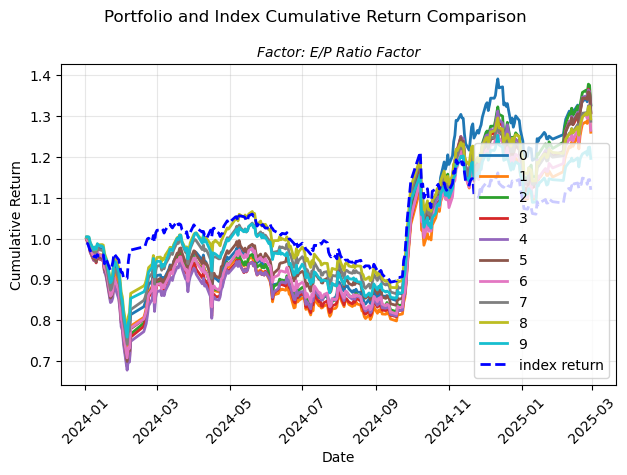

In [15]:
#画图，每组收益率曲线
labels = [i for i in range(10)]

plt.figure()
for pfl in labels:
    pfl_cumret = df_pfl_mkt[df_pfl_mkt['pfl_num']==pfl].copy()
    plt.plot(pfl_cumret['trade_dt'], pfl_cumret['cum_ret'], label=pfl, linewidth=2)
plt.plot(df_mkt_temp['trade_dt'],df_mkt_temp['cum_mktret'],'b--',label='index return',linewidth=2)


plt.suptitle('Portfolio and Index Cumulative Return Comparison')
plt.title('Factor: {}'.format('E/P Ratio Factor'), fontsize=10, style='italic') 
plt.ylabel('Cumulative Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

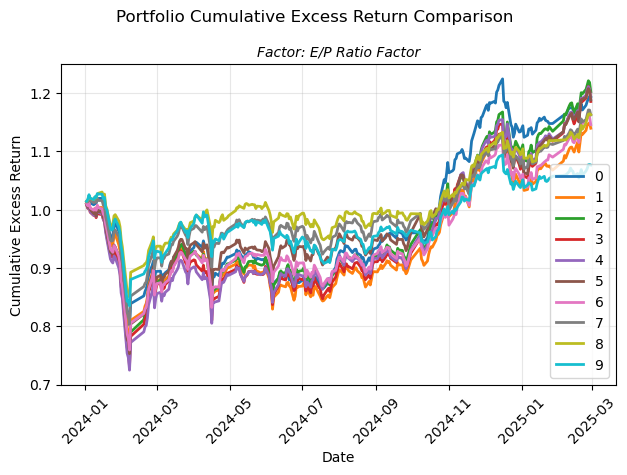

In [16]:
#画图，每组相对中证800指数超额收益率曲线
labels = [i for i in range(10)]

plt.figure()
for pfl in labels:
    pfl_cumret = df_pfl_mkt[df_pfl_mkt['pfl_num']==pfl].copy()
    plt.plot(pfl_cumret['trade_dt'], pfl_cumret['cum_excess_ret_index'], label=pfl, linewidth=2)
    
plt.suptitle('Portfolio Cumulative Excess Return Comparison')
plt.title('Factor: {}'.format('E/P Ratio Factor'), fontsize=10, style='italic') 
plt.ylabel('Cumulative Excess Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

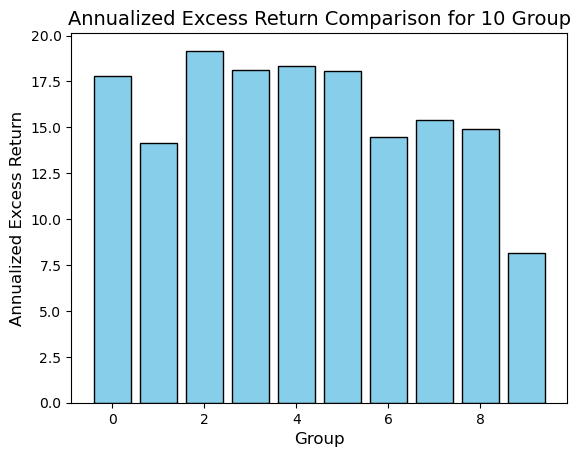

In [17]:
#画图，年化超额收益
excess_return = df_pfl_mkt.groupby('pfl_num')['pfl_ret_index'].mean().reset_index()
excess_return['pfl_ret_index'] = excess_return['pfl_ret_index'] * 252 #年化收益率

plt.bar(excess_return['pfl_num'], excess_return['pfl_ret_index'],color='skyblue',edgecolor='black')   
plt.xlabel('Group', fontsize=12)
plt.ylabel('Annualized Excess Return', fontsize=12)
plt.title('Annualized Excess Return Comparison for 10 Group', fontsize=14)
plt.show()

In [18]:
#获取夏普比率
def sharpe_ratio(df, rf=0.017):

    df['pfl_ret_rf'] =  df['pfl_return'] - rf
    mean_excess = df.groupby('pfl_num')['pfl_ret_rf'].mean()
    std_excess = df.groupby('pfl_num')['pfl_ret_rf'].std()
    
    #年化夏普比率
    sharpe_ratio = (mean_excess * 252) / (std_excess * np.sqrt(252))
    
    return sharpe_ratio
    
sharpe_ratio = sharpe_ratio(df_pfl_mkt)
for i in range(10):
    print(f"Sharpe Ratio for group {i} is: ", f"{sharpe_ratio[i]:.6f}")

Sharpe Ratio for group 0 is:  0.842794
Sharpe Ratio for group 1 is:  0.656527
Sharpe Ratio for group 2 is:  0.782593
Sharpe Ratio for group 3 is:  0.734353
Sharpe Ratio for group 4 is:  0.739474
Sharpe Ratio for group 5 is:  0.738245
Sharpe Ratio for group 6 is:  0.666960
Sharpe Ratio for group 7 is:  0.737191
Sharpe Ratio for group 8 is:  0.794584
Sharpe Ratio for group 9 is:  0.545028


In [19]:
# 因子IC表现
# 获取IC序列
def get_factor_ic(df_ret, df_factor, factor='factor_style_neutral'):
    '''
    获取因子IC
    df_ret: dataframe包括列名:date(ymd),stk_code, daily_return,month
    df_factor: dataframe包括列名: date(ymd),stk_code,daily_factor,month
    '''
    df_ret = df_ret.copy()
    df_factor = df_factor.copy()
    
    df_ret.sort_values(by=['trade_dt','s_info_windcode'],inplace=True)
    df_factor.sort_values(by=['trade_dt','s_info_windcode'],inplace=True)
    
    #合并月末factor以及下一个月的return
    factor_last = df_factor.drop_duplicates(subset=['s_info_windcode','month'],keep='last').copy() #保留月末数据
    factor_last[factor] = factor_last.groupby('s_info_windcode')[factor].shift(1) #factor向后一个月移动
    
    df_ret['month_stk_ret'] = df_ret.groupby(['s_info_windcode','month'])['stk_ret']\
                                    .apply(lambda x: (1 + x*0.01).cumprod())#将日收益率转化为月收益率
    df_ret = df_ret.drop_duplicates(subset=['s_info_windcode','month'],keep='last')#保留月末数据
    
    df_merge = pd.merge(factor_last[['s_info_windcode','month',factor]],\
                        df_ret[['s_info_windcode','month','month_stk_ret']], on=['s_info_windcode','month'], how='inner')
    df_merge.dropna(subset=['month_stk_ret',factor],inplace=True)
    
    def cal_corr(df):
        return df.corr().iloc[0,1]
    
    df_ic = df_merge.groupby('month')[[factor,'month_stk_ret']].apply(cal_corr).reset_index()
    df_ic.columns = ['date', 'IC']
    return df_ic


# 分析IC表现
def analysis_factor_ic(df_ret, df_factor,factor='factor_style_neutral'):
    '''
    df_ret: dataframe包括列名:date(ymd),stk_code,daily_return,month
    df_factor: dataframe包括列名: date(ymd),stk_code,factor,month
    '''
    df_ic = get_factor_ic(df_ret, df_factor)
    ic_mean = df_ic['IC'].mean()
    ic_std = df_ic['IC'].std()
    ir_ratio = ic_mean / ic_std
    ic0_ratio = 100 * len(df_ic.loc[df_ic['IC'] > 0, :]) / len(df_ic)
    ic002_ratio = 100 * len(df_ic.loc[df_ic['IC'] > 0.02, :]) / len(df_ic)
    
    dct = {
        '因子名称': factor,
        'IC均值': ic_mean,
        'IC标准差': ic_std,
        'IR比率': ir_ratio,
        'IC>0的比例(%)': ic0_ratio,
        'IC>0.02的比例(%)': ic002_ratio,
    }
    
    return dct

# 因子IC结果
print('E/P Factor IC Performance')
print(get_factor_ic(df_stk_factor[['trade_dt','s_info_windcode','stk_ret','month']], \
                    df_stk_factor[['trade_dt','s_info_windcode','factor_style_neutral','month']]),'\n')
print(analysis_factor_ic(df_stk_factor[['trade_dt','s_info_windcode','stk_ret','month']], \
                         df_stk_factor[['trade_dt','s_info_windcode','factor_style_neutral','month']]),'\n')

E/P Factor IC Performance
       date        IC
0   2024-02  0.068038
1   2024-03  0.003364
2   2024-04  0.064584
3   2024-05  0.074322
4   2024-06  0.038837
5   2024-07 -0.105238
6   2024-08  0.020901
7   2024-09 -0.072243
8   2024-10 -0.144474
9   2024-11 -0.001158
10  2024-12  0.037197
11  2025-01  0.003022
12  2025-02 -0.062156 

{'因子名称': 'factor_style_neutral', 'IC均值': -0.005769495606372124, 'IC标准差': 0.06968509058598904, 'IR比率': -0.08279383090207455, 'IC>0的比例(%)': 61.53846153846154, 'IC>0.02的比例(%)': 46.15384615384615} 

